## 1. Setup

In [3]:
%pip install -q numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns",50)
sns.set_style("whitegrid")

**2.Load DataSet**

In [5]:
df = pd.read_csv("titanic_dataset.csv")

In [6]:
df.shape

(782, 15)

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [9]:
# Identify numerical and categorical features
num_cols = ["age","fare","sibsp","parch"]
cat_cols = ["survived","pclass","sex","embarked","who","adult_male","deck","embark_town","alone"]

print("\nNumerical columns:",num_cols)
print("Categorical columns:",cat_cols)


Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['survived', 'pclass', 'sex', 'embarked', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


### 3. Numerical Features = Analysis

In [10]:
# Force 'age' column to numeric, turning invalid strings into NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Verify the data type is now float64
print(df['age'].dtype)

float64


In [11]:
df[["age","fare"]].head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [12]:
df[num_cols].head()

,age,fare,sibsp,parch
0,22.0,7.2500,1.0,0.0
1,38.0,71.2833,1.0,0.0
2,26.0,7.9250,0.0,0.0
3,35.0,53.1000,1.0,0.0
4,35.0,8.0500,0.0,0.0


In [13]:
print(df[num_cols].dtypes)

age      float64
fare     float64
sibsp    float64
parch    float64
dtype: object


3.1. Summary Statistics

In [14]:
print("Summary Statistics:")
df[num_cols].describe()

Summary Statistics:


,age,fare,sibsp,parch
count,622.000000,781.000000,781.000000,781.000000
mean,29.966109,33.225095,0.510883,0.372599
std,14.576037,52.032466,1.032273,0.802699
min,0.670000,0.000000,0.000000,0.000000
25%,21.000000,7.925000,0.000000,0.000000
50%,28.000000,14.500000,0.000000,0.000000
75%,38.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


3.2. Mean,Median,Mode

In [15]:
print("Mean:")
print(df[num_cols].mean())

print("-"*50)

print("Median:")
print(df[num_cols].median())
print("-"*50)

print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
age      29.966109
fare     33.225095
sibsp     0.510883
parch     0.372599
dtype: float64
--------------------------------------------------
Median:
age      28.0
fare     14.5
sibsp     0.0
parch     0.0
dtype: float64
--------------------------------------------------
Mode:
age      24.00
fare      8.05
sibsp     0.00
parch     0.00
Name: 0, dtype: float64


In [16]:
df["parch"].mode()

0    0.0
Name: parch, dtype: float64

In [17]:
print(df["age"].mode()[0])

24.0


In [18]:
print(df[["age","fare"]].mode())

    age  fare
0  24.0  8.05


In [19]:
print(df[["age","fare"]].mode().iloc[0])

age     24.00
fare     8.05
Name: 0, dtype: float64


### 3.3. Variance & Standard Deviation

In [20]:
print("Variance:")
print(df[num_cols].var())

print("Standard Deviation:")
print(df[num_cols].std())

Variance:
age       212.460861
fare     2707.377526
sibsp       1.065587
parch       0.644325
dtype: float64
Standard Deviation:
age      14.576037
fare     52.032466
sibsp     1.032273
parch     0.802699
dtype: float64


### 3.4. Skewness & kurtosis

In [21]:
print("\nSkewness:")
print(df[num_cols].skew())

print("\nKurtosis:")
print(df[num_cols].kurtosis())


Skewness:
age      0.399220
fare     4.671024
sibsp    3.504373
parch    2.805355
dtype: float64

Kurtosis:
age       0.131343
fare     31.133542
sibsp    16.835954
parch    10.154927
dtype: float64


### 3.5 Histogram

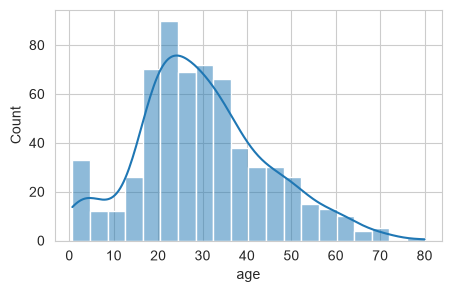

In [22]:
plt.figure(figsize=(5,3))
sns.histplot(df["age"],kde=True)
plt.show()

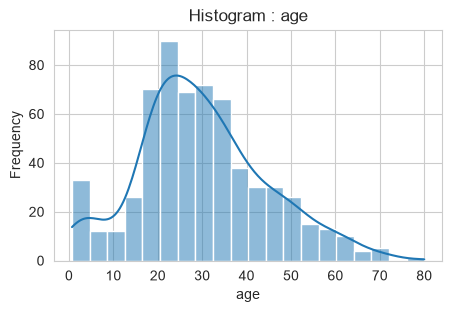

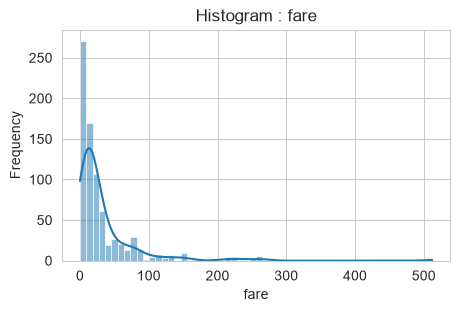

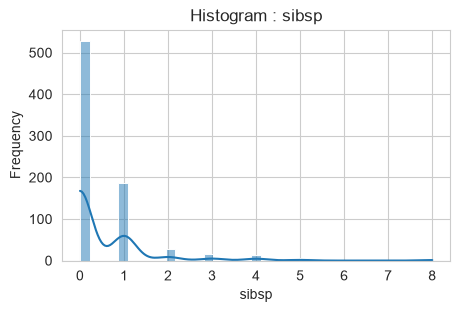

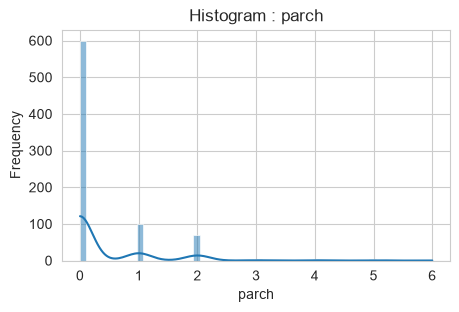

In [23]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram : {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show

### 3.6.Boxplots

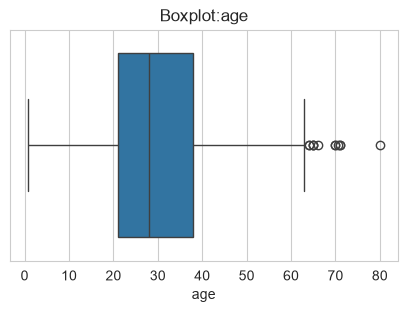

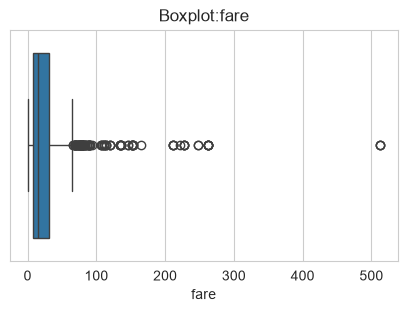

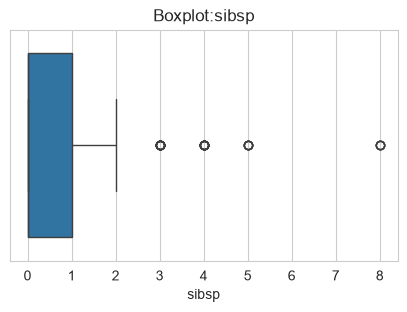

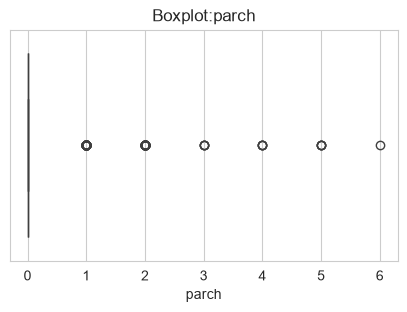

In [24]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot:{col}")
    plt.xlabel(col)
    plt.show()

### 4.Categorical Features - Analysis

In [25]:
df[cat_cols].head()

,survived,pclass,sex,embarked,who,adult_male,deck,embark_town,alone
0,0,3,male,S,man,True,NaN,Southampton,False
1,1,1,female,C,woman,False,C,Cherbourg,False
2,1,3,female,S,woman,False,NaN,Southampton,True
3,1,1,female,S,woman,False,C,Southampton,False
4,0,3,male,S,man,True,NaN,Southampton,True


### 5.1. Frequency Table

In [26]:
df["pclass"].value_counts()

pclass
3    427
1    191
2    164
Name: count, dtype: int64

In [28]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [27]:
df["pclass"].value_counts(normalize=True)

pclass
3    0.546036
1    0.244246
2    0.209719
Name: proportion, dtype: float64

In [29]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))
    print("-"*50)

Frequency table for survived
survived
0    478
1    304
Name: count, dtype: int64
Proportion for survived
survived
0    0.611253
1    0.388747
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for pclass
pclass
3    427
1    191
2    164
Name: count, dtype: int64
Proportion for pclass
pclass
3    0.546036
1    0.244246
2    0.209719
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for sex
sex
male      504
female    278
Name: count, dtype: int64
Proportion for sex
sex
male      0.644501
female    0.355499
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for embarked
embarked
S    563
C    146
Q     71
Name: count, dtype: int64
Proportion for embarked
embarked
S    0.721795
C    0.187179
Q    0.091026
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for who
who
man      474
woman    238


### 5.2.CountPlot

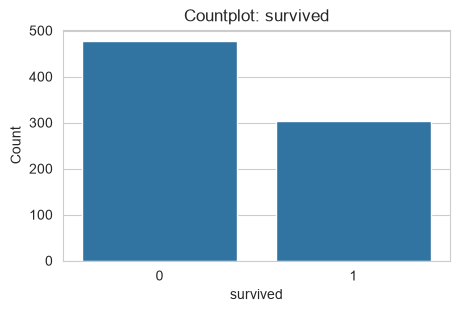

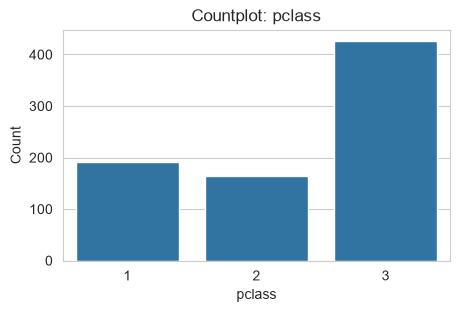

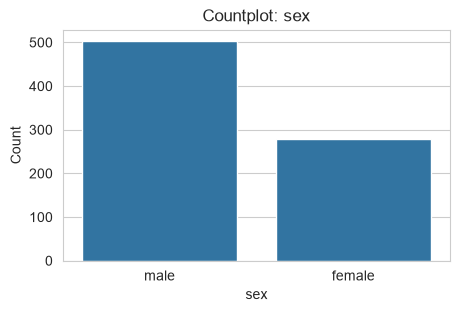

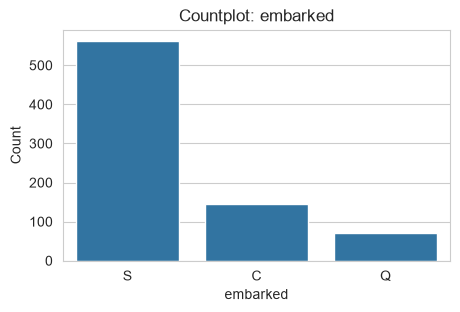

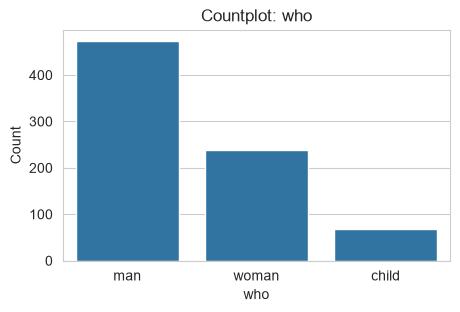

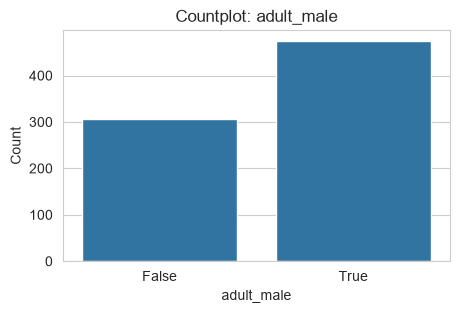

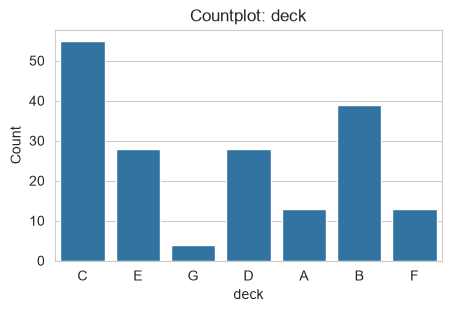

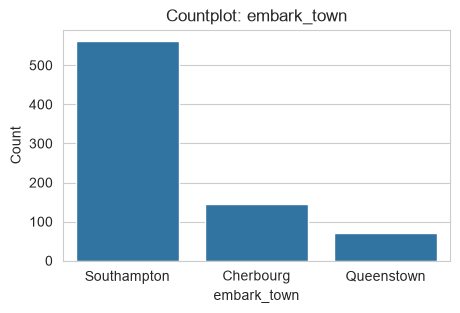

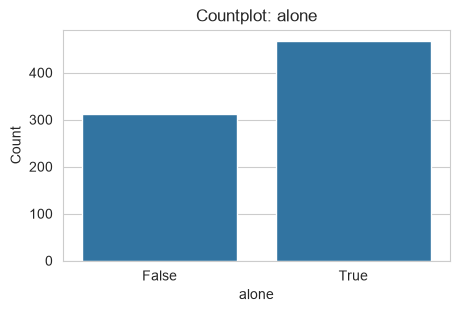

In [30]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [31]:
print("Univariate anlysis completed.")
print("-Numerical statistics calculated")
print("-Skewness and kurtosis printed")
print("-Histogram and boxplots plotted")
print("-Categorical frequency and countplots created")

Univariate anlysis completed.
-Numerical statistics calculated
-Skewness and kurtosis printed
-Histogram and boxplots plotted
-Categorical frequency and countplots created
